In [14]:
import matplotlib.pyplot as plt
import pandas as pd

import os

input_directory = r"E:\Users\Sebastian_van_Dijk\TEMP"
organoids = ["TL01", "TL09","TL10","TL11","TL12","TL31"]
dirs = []
for organoid in organoids:
    dir_path = os.path.join(input_directory, organoid, "properties")
    dirs.append(dir_path)

all_df = pd.DataFrame()
for organoid, directory in zip(organoids, dirs):
    for file in os.listdir(directory):
        if file.endswith(".txt"):
            df = pd.read_csv(os.path.join(directory, file), sep="\t")
            if organoid == "TL01":
                df["type"] = "WT"
            elif organoid == "TL26":
                df["type"] = "CRC"
            else:
                df["type"] = "mixed"
            df["organoid"] = organoid
            all_df = pd.concat([all_df, df], ignore_index=True)

all_df["ratioWT_CRC"] = all_df["raw_WT"] / all_df["raw_CRC"]

In [15]:
df

,label,z,y,x,bounding_box,volume,area_WT,raw_WT,area_CRC,raw_CRC,Phenotype,type,organoid
0,1,1.592878,31.710720,145.026432,"(0, 17, 121, 5, 50, 172)",2724.0,2724.0,107.593245,2724.0,139.082232,CRC,mixed,TL31
1,2,0.502924,66.688304,178.958480,"(0, 51, 162, 2, 84, 198)",1710.0,1710.0,107.840351,1710.0,147.695322,CRC,mixed,TL31
2,3,0.428212,75.352645,115.767003,"(0, 60, 105, 2, 90, 127)",794.0,794.0,108.108312,794.0,129.226700,CRC,mixed,TL31
3,4,0.500000,87.396175,198.342896,"(0, 74, 188, 2, 102, 209)",732.0,732.0,108.256831,732.0,148.155738,CRC,mixed,TL31
4,5,0.365912,100.827175,150.847437,"(0, 85, 141, 2, 117, 162)",839.0,839.0,108.052443,839.0,129.520858,CRC,mixed,TL31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,306,22.197531,202.190329,213.412551,"(21, 189, 203, 24, 216, 223)",972.0,972.0,107.884774,972.0,114.017490,CRC,mixed,TL31
306,307,21.000000,211.465909,138.431818,"(21, 204, 132, 22, 221, 146)",176.0,176.0,108.034091,176.0,117.556818,CRC,mixed,TL31
307,308,21.515982,220.223744,237.465753,"(21, 214, 232, 23, 227, 244)",219.0,219.0,107.214612,219.0,121.447489,CRC,mixed,TL31
308,309,22.165574,229.445902,208.193443,"(21, 221, 198, 24, 238, 218)",610.0,610.0,107.824590,610.0,117.613115,CRC,mixed,TL31


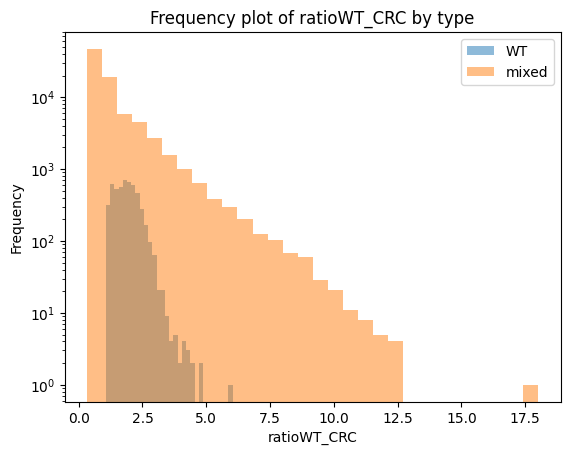

In [13]:
for t in all_df["type"].unique():
    subset = all_df[all_df["type"] == t]
    plt.hist(subset["ratioWT_CRC"], bins=30, alpha=0.5, label=t)

plt.xlabel("ratioWT_CRC")
plt.ylabel("Frequency")
plt.title("Frequency plot of ratioWT_CRC by type")
plt.yscale("log")  # Make y-axis logarithmic
plt.legend()
plt.show()

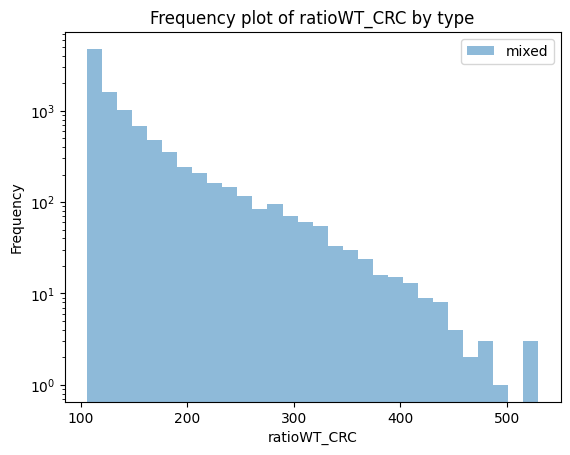

In [18]:
subset = all_df[all_df["organoid"] == "TL11"]
plt.hist(subset["raw_WT"], bins=30, alpha=0.5, label=t)

plt.xlabel("ratioWT_CRC")
plt.ylabel("Frequency")
plt.title("Frequency plot of ratioWT_CRC by type")
plt.yscale("log")  # Make y-axis logarithmic
plt.legend()
plt.show()

In [ ]:
import tifffile
import esda
import libpysal
import numpy as np

import os


image = tifffile.imread(r"E:\Users\Sebastian_van_Dijk\TEMP\TL11\projXY.tif")[:, row_min:row_max, col_min:col_max]

XZ = np.stack(image, axis=1)


In [6]:
import tifffile
from scipy import ndimage
import os

input_directory = r"C:\Users\6331823\Desktop\Train model whole organoid segmentation"
for organoid in os.listdir(input_directory):
    if organoid.endswith(".tif"):
        original = os.path.join(input_directory, organoid)
        original = tifffile.imread(original)
        resize_factors = (200 / original.shape[0] , 200 / original.shape[1])
        XY = ndimage.zoom(original, resize_factors, order=0)
        XY = ndimage.gaussian_filter(XY, sigma=(2, 2))
        tifffile.imwrite(
            os.path.join(input_directory, "smoothed_XY", organoid),
            XY,
        )

In [17]:
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd

# Your ratio data
ratios = np.array([
    0.843218545, 0.844873502, 1.668776133, 0.862274271, 0.809498911,
    0.737159537, 0.845353398, 0.775946006, 0.674322713, 0.649706156,
    1.112518394, 0.81620095, 1.705073941, 0.753885069, 0.77938578,
    0.793327383, 1.982575108, 0.737841096, 0.704847086, 0.701849541,
    0.847186436, 0.688447415, 0.695395085, 0.757498956, 1.13937129,
    2.126445938, 0.866231304, 2.3231805, 0.77348789, 0.761823995,
    0.773913337, 0.693962019, 0.760776805, 1.720121879, 0.753178687,
    1.351161179, 1.430329714, 0.846986397, 0.735142857, 1.350898729,
    1.972850816, 1.428831122, 1.641974047, 1.413566286, 0.810866686,
    0.837289092, 1.257008415, 0.869855683, 0.873884474, 0.865940501,
    0.908263305, 1.440489263, 1.289546879, 0.784626411, 0.888552437,
    0.822779145, 0.84824339
]).reshape(-1, 1)  # reshape for sklearn

for frame in range(14):
    ratios = pd.read_csv(f"E:\\Users\\Sebastian_van_Dijk\\Data_Anna\\s65\\properties\\Frame-{frame}_props.csv")
    ratios = ratios["wt_crc_ratio"].to_numpy().reshape(-1, 1)

    # Run KMeans with 2 clusters
    kmeans = KMeans(n_clusters=2, random_state=0)
    labels = kmeans.fit_predict(ratios)
    centers = kmeans.cluster_centers_.flatten()

    # Sort cluster centers to get lower and upper cluster means
    centers.sort()
    cutoff = (centers[0] + centers[1]) / 2

    print(f"frame: {frame}")
    print("Cluster centers:", centers)
    print("Estimated cutoff value:", cutoff)
    #cutoff = 1

    print(f"CRC cells: {np.sum(ratios.flatten() < cutoff)}")
    print(f"WT cells: {np.sum(ratios.flatten() >= cutoff)}\n")


frame: 0
Cluster centers: [0.80490334 1.5987637 ]
Estimated cutoff value: 1.201833517612973
CRC cells: 38
WT cells: 17

frame: 1
Cluster centers: [0.81025005 1.59913951]
Estimated cutoff value: 1.2046947819564797
CRC cells: 56
WT cells: 18

frame: 2
Cluster centers: [0.8431325  1.75521769]
Estimated cutoff value: 1.2991750972770781
CRC cells: 83
WT cells: 17

frame: 3
Cluster centers: [0.84671004 1.62655394]
Estimated cutoff value: 1.2366319891124362
CRC cells: 112
WT cells: 20

frame: 4
Cluster centers: [0.86165762 1.63344464]
Estimated cutoff value: 1.247551133147449
CRC cells: 159
WT cells: 22

frame: 5
Cluster centers: [0.85421118 1.63587196]
Estimated cutoff value: 1.245041572590544
CRC cells: 205
WT cells: 24

frame: 6
Cluster centers: [0.85839238 1.73696882]
Estimated cutoff value: 1.2976806005872792
CRC cells: 259
WT cells: 23

frame: 7
Cluster centers: [0.84025978 1.52140253]
Estimated cutoff value: 1.1808311579876176
CRC cells: 319
WT cells: 34

frame: 8
Cluster centers: [0.8